# DSC 340 Lab 1: Home Credit Default Risk Logistic Regression

Rothavy Kong, Lucy Synnestvedt

DSC 340 S26  
Project 1: Home Credit Default Risk Logistic Regression 

For this assignment we will use the Home Credit Default Risk Datasets, available on Kaggle and GitHub, to predict whether a loan applicant will default.

Dataset: https://www.kaggle.com/competitions/home-credit-default-risk

## Business Problem Overview

Our bank needs to determine whether a loan applicant is likely to repay or default on a loan. Making inaccurate lending decisions can lead to alot of financial losses from defaults or missed revenue from rejecting reliable borrowers.

To solve the problem, we plan on building a logistic regression model to predict whether loan applicant will default or repay the loan. We believe that this will help us make better decisions when it comes to risk management, help our bank remain stable and maximize our probablistic profit optimization.

In terms of success for our model, we want to catch as many risky loan applicants before we approve their loans to prevent our bank from major financial losses.

To achieve this, we decide to look at a few key metrics.
- Recall: we want to priortizie high recall score because we want to minimize the number of loan applicant who will default.
- AUC and precision: we want to ensure that our model still maintains good overall performance.

Target variable definition
- Target = 0 : Applicant repays the loan
- Target = 1 : Applicant defaults on the loan

## Import Libraries

Before we begin the analysis, we import all libraries used throughout the pipeline:

* **Pandas**: data analysis, manipulation, and merging of our four datasets.
* **NumPy**: numerical operations and array handling used in feature engineering.
* **Matplotlib and Seaborn**: data visualization including correlation heatmaps, confusion matrices, and ROC curves.
* **Scikit-learn**: encoding categorical variables, handling missing data via iterative and simple imputation, scaling features, building our logistic regression model, and evaluating performance through cross-validation and classification metrics.
* **SciPy**: statistical testing to distinguish between MAR and MCAR missing data patterns.


In [1]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline

# Modeling & Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay
)
from sklearn.feature_selection import mutual_info_classif

# Statistics
from scipy import stats

# Settings
import warnings
warnings.filterwarnings('ignore')

## Loading Data
We load the main application dataset and merge three supplementary tables: bureau, previous_application, and installments_payments.

These datasets provide more historical and behavioral information about each applicant, which can improve the predictiveness of our model.

The bureau dataset contains information about applicants’ credit history with other financial institutions. While an applicant’s credit behavior with Home Credit may appear clean, their broader financial behavior across institutions may reveal additional risk signals. This dataset captures important indicators such as the number of active versus closed credit lines, overdue payments with other banks, total outstanding debt, and the length of the applicant’s credit history. Incorporating these features helps provide a more complete view of the applicant’s financial obligations and creditworthiness.

The previous_application dataset includes information about applicants’ past loan applications with Home Credit. These records provide insight into historical interactions between the applicant and the institution, including whether previous applications were approved, refused, or canceled, the reasons for past refusals, and the interest rate tiers assigned to prior loans. These historical outcomes can act as strong predictive signals, as past lending decisions and applicant behavior may correlate with future default risk.

Finally, the installments_payments dataset captures detailed repayment behavior for previously issued loans. It contains transactional level information such as payment timing, the number of days payments were late, and the frequency of missed or delayed payments. These repayment behavior metrics are particularly valuable because they reflect how reliably a customer fulfills their financial obligations once a loan is issued.

By merging these tables, we believe that our model will be able to capture better patterns associated with loan repayment and default risk.

In [2]:
# Main application dataset
main_df = pd.read_csv("application_train.csv")

# Bureau table (credit history with other institutions)
bureau_df = pd.read_csv("bureau.csv")

# Previous application table
prev_df = pd.read_csv("previous_application.csv")

# Installment payments table
inst_df = pd.read_csv("installments_payments.csv")

## Exploratory Data Analysis
We believe that it is very important to conduct Exploratory Data Analysis before any thought of model-building. It is important to explore the dataset first so that we have a better understanding of the problem that we are working with. To do so, we will use Pandas to get the general information from the dataset. To start, we will look at the imbalance of TARGET, shape of the dataset, column names, data types, list of categorical and numerical variables and number of non-null values. This will help us understand the dataset better. 

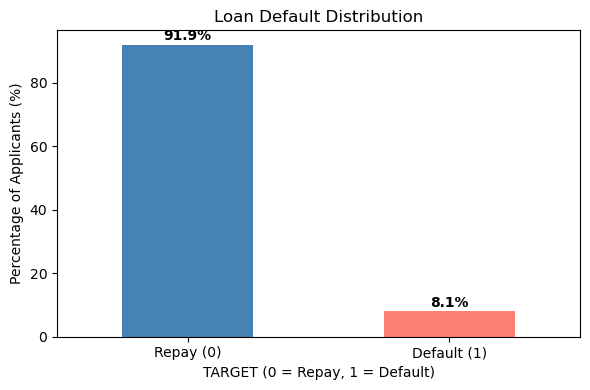

Class imbalance: 91.9% repay vs 8.1% default


In [3]:
# Loan Default Distribution
percentages = main_df['TARGET'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = percentages.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])

# Add percentage labels on bars
for i, v in enumerate(percentages):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_title('Loan Default Distribution')
ax.set_xlabel('TARGET (0 = Repay, 1 = Default)')
ax.set_ylabel('Percentage of Applicants (%)')
ax.set_xticklabels(['Repay (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

print(f"Class imbalance: {percentages[0]:.1f}% repay vs {percentages[1]:.1f}% default")

In [4]:
# Get shape of dataset
print("The shape of main dataset is:",main_df.shape)
print("The shape of bureau table is:",bureau_df.shape)
print("The shape of previous application table is:",prev_df.shape)
print("The shape of installments payments table is:",inst_df.shape)

The shape of main dataset is: (307511, 122)
The shape of bureau table is: (1716428, 17)
The shape of previous application table is: (1670214, 37)
The shape of installments payments table is: (13605401, 8)


In [5]:
# Get summary of missing values %
# Main dataframe
missing_summary_1 = pd.DataFrame({
    "Missing Count": main_df.isnull().sum(),
    "Missing %": main_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_1 = missing_summary_1[missing_summary_1["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for main dataset:", missing_summary_1)

# Bureau table
missing_summary_2 = pd.DataFrame({
    "Missing Count": bureau_df.isnull().sum(),
    "Missing %": bureau_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_2 = missing_summary_2[missing_summary_2["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for bureau table:", missing_summary_2)

# Previous application table
missing_summary_3 = pd.DataFrame({
    "Missing Count": prev_df.isnull().sum(),
    "Missing %": prev_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_3 = missing_summary_3[missing_summary_3["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for previous application table:", missing_summary_3)

# Installments payments table
missing_summary_4 = pd.DataFrame({
    "Missing Count": inst_df.isnull().sum(),
    "Missing %": inst_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)
missing_summary_4 = missing_summary_4[missing_summary_4["Missing %"] > 50]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display("Missing summary for installments payments table:", missing_summary_4)

'Missing summary for main dataset:'

,Missing Count,Missing %
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


'Missing summary for bureau table:'

,Missing Count,Missing %
AMT_ANNUITY,1226791,71.473490
AMT_CREDIT_MAX_OVERDUE,1124488,65.513264


'Missing summary for previous application table:'

,Missing Count,Missing %
RATE_INTEREST_PRIVILEGED,1664263,99.643698
RATE_INTEREST_PRIMARY,1664263,99.643698
AMT_DOWN_PAYMENT,895844,53.636480
RATE_DOWN_PAYMENT,895844,53.636480


'Missing summary for installments payments table:'

,Missing Count,Missing %


## Drop Columns with missing data
In this step, we will handle missing data in our datasets by dropping columns with a missing percentage above 50%. According to the summary table above, only the Main dataset, Bureau table and Previous Application table have missing data percentages above this threshold.

We decided to handle missing data by only dropping columns at this stage because we want to examine multicollinearity and perform feature engineering before merging the datasets. We do not want to work with data that we already know has a missing percentage above 50%, which is why we chose to drop these columns and not do any imputation yet to avoid data leakage. Later on, after we split the data into training and test sets, we will handle the remaining missing data through imputation.

In [6]:
# Drop columns with missing data > 50%
# Main Dataset
threshold = len(main_df) * 0.5
main_df = main_df.dropna(axis=1, thresh=threshold)

# Bureau Dataset
threshold = len(bureau_df) * 0.5
bureau_df = bureau_df.dropna(axis=1, thresh=threshold)

# Previous application Dataset
threshold = len(prev_df) * 0.5
prev_df = prev_df.dropna(axis=1, thresh=threshold)

## Variable Selection Process for Main Dataset
In this step, we will look at our main dataset which is the applicaton_train dataset and we will look at which variables to choose and which features we should engineer to further increase the predictivness of our model.

Before choosing the variables for our model building, we decide to ask a few important questions about the loan applicant.  

1. Can they afford the loan?
2. Are they financially stable?
3. Have they struggled with credit before?
4. Are they showing risky payment behavior in the past?
5. Who are they demographically?

To answer these questions, we decided to look into each variables description that will help us answer the questions better and categorize each variables into: Demographic Characteristics, Employment and Income Stability, Financial Behavior and Credit History, Application and Administrative Information, Loan and Contract Characteristics, Housing and Asset Ownership, Geographic Risk Indicators.

These are some of the columns that we consider using in our model. 

Demographic Characteristics
- NAME_EDUCATION_TYPE
- DAYS_BIRTH
- CNT_FAM_MEMBERS
- NAME_FAMILY_STATUS

Employment and Income Stability
- DAYS_EMPLOYED
- NAME_INCOME_TYPE

Financial Behavior and Credit History
- AMT_REQ_CREDIT_BUREAU_YEAR
- DEF_60_CNT_SOCIAL_CIRCLE
- EXT_SOURCE_2
- EXT_SOURCE_3

Application and Administrative Information
- DAYS_REGISTRATION
- DAYS_ID_PUBLISH
- DAYS_LAST_PHONE_CHANGE

Loan and Contract Characteristics
- NAME_CONTRACT_TYPE
- ANNUITY_INCOME_RATIO
- LOAN_INCOME_RATIO

Housing and Asset Ownership
- FLAG_OWN_REALTY
- FLAG_OWN_CAR
- NAME_HOUSING_TYPE

Geographic Risk Indicators
- REGION_RATING_CLIENT
- REGION_RATING_CLIENT_W_CITY

## Multicollinearity and Feature Engineering
We will look at multicollinearity between features in each dataset before merging. We believe it is important to handle multicollinearity because when two variables contain redundant information, these features might introduce noise and inflate the variance of our coefficients and make them unstable, difficult to intepret. So to address this, we create a correlation matrix for each table and identify pairs above a 65% correlation threshold. Rather than simply dropping one of the correlated features, we engineer new features that would best capture the information from both variables before dropping the original.

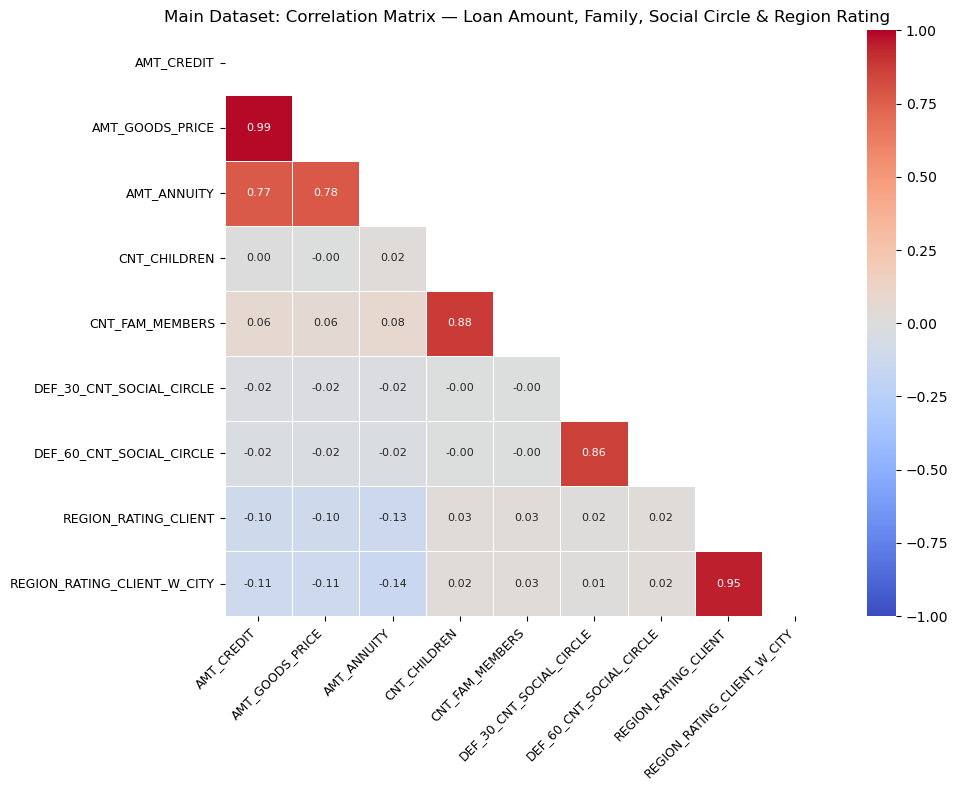

  Variables with Correlation ABOVE 65%
AMT_GOODS_PRICE & AMT_CREDIT
→ Correlation: 0.99 (positive)

REGION_RATING_CLIENT_W_CITY & REGION_RATING_CLIENT
→ Correlation: 0.95 (positive)

CNT_FAM_MEMBERS & CNT_CHILDREN
→ Correlation: 0.88 (positive)

DEF_60_CNT_SOCIAL_CIRCLE & DEF_30_CNT_SOCIAL_CIRCLE
→ Correlation: 0.86 (positive)

AMT_ANNUITY & AMT_GOODS_PRICE
→ Correlation: 0.78 (positive)

AMT_ANNUITY & AMT_CREDIT
→ Correlation: 0.77 (positive)

  Total highly correlated pairs found: 6


In [7]:
# Main dataset Correlation matrix
corr = main_df[['AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY',
                 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
                 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
                 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8},
    vmin=-1, vmax=1
)
plt.title("Main Dataset: Correlation Matrix — Loan Amount, Family, Social Circle & Region Rating")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

After looking the correlation matrix, we identified 6 highly correlated pairs 
above our 65% threshold. Here is what we decide to do:

There is a 99% correlation between AMT_GOODS_PRICE and AMT_CREDIT, a 78% correlation between AMT_ANNUITY and AMT_GOODS_PRICE, and a 77% correlation between AMT_ANNUITY and AMT_CREDIT. We decided to drop all three raw variables to resolve the multicollinearity. In their place, we engineered two new features ANNUITY_INCOME_RATIO and LOAN_INCOME_RATIO which capture affordability relative to the applicant's income rather than raw dollar amounts.

There is an 88% correlation between CNT_CHILDREN and CNT_FAM_MEMBERS. We decided to keep CNT_FAM_MEMBERS over CNT_CHILDREN because CNT_FAM_MEMBERS takes into account all members of the family and will give more detail to the model.

There is an 86% correlation between DEF_30_CNT_SOCIAL_CIRCLE and DEF_60_CNT_SOCIAL_CIRCLE. We decided to keep DEF_60_CNT_SOCIAL_CIRCLE and drop DEF_30_CNT_SOCIAL_CIRCLE because the 60-day window captures more serious and sustained 
default behavior, which is a stronger signal for credit risk.

There is a 95% correlation between REGION_RATING_CLIENT and REGION_RATING_CLIENT_W_CITY. We decided to keep REGION_RATING_CLIENT_W_CITY because it has a higher granularity. Having a higher granularity will give more detail to the model.

In [8]:
# Feature engineering
main_df["ANNUITY_INCOME_RATIO"] = main_df["AMT_ANNUITY"]/main_df["AMT_INCOME_TOTAL"]
main_df["LOAN_INCOME_RATIO"] = main_df["AMT_CREDIT"]/main_df["AMT_INCOME_TOTAL"]

In [9]:
# Drop features 
main_df = main_df.drop(columns=[
    'AMT_GOODS_PRICE',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'CNT_CHILDREN',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'REGION_RATING_CLIENT'
])

In [10]:
# Final Variable Selection for main dataset
application_df = main_df[['SK_ID_CURR','TARGET','NAME_EDUCATION_TYPE','ANNUITY_INCOME_RATIO',
'LOAN_INCOME_RATIO','DAYS_REGISTRATION','DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE',
'AMT_REQ_CREDIT_BUREAU_YEAR','DEF_60_CNT_SOCIAL_CIRCLE','DAYS_EMPLOYED','DAYS_BIRTH',
'CNT_FAM_MEMBERS','REGION_RATING_CLIENT_W_CITY','EXT_SOURCE_2','EXT_SOURCE_3','NAME_CONTRACT_TYPE','FLAG_OWN_REALTY','FLAG_OWN_CAR',
'NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','CODE_GENDER']]

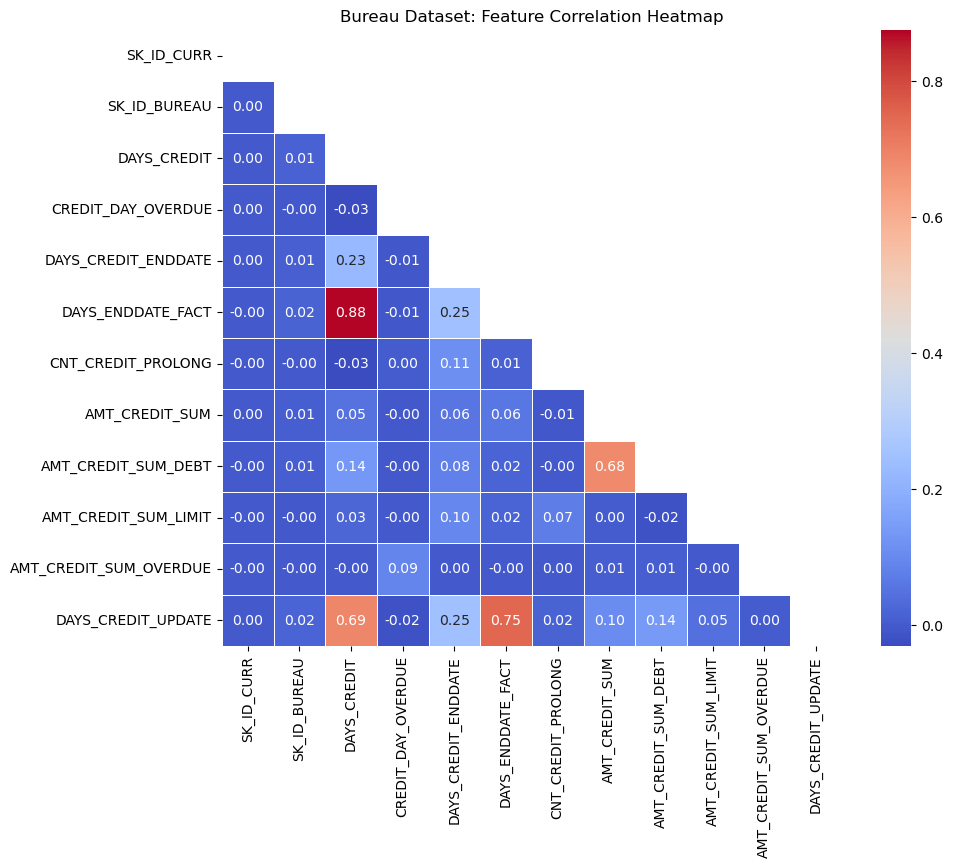

  Variables with Correlation ABOVE 65%
DAYS_ENDDATE_FACT & DAYS_CREDIT
→ Correlation: 0.88 (positive)

DAYS_CREDIT_UPDATE & DAYS_ENDDATE_FACT
→ Correlation: 0.75 (positive)

DAYS_CREDIT_UPDATE & DAYS_CREDIT
→ Correlation: 0.69 (positive)

AMT_CREDIT_SUM_DEBT & AMT_CREDIT_SUM
→ Correlation: 0.68 (positive)

  Total highly correlated pairs found: 4


In [11]:
# Bureau Correlation matrix
corr = bureau_df.select_dtypes(include='number').corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Bureau Dataset: Feature Correlation Heatmap")
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

According to the correlation matrix above, we see there are 4 highly correlated pairs found. Here is a breakdown of each highly correlated pairs and how we plan to handle them.

- Days Credit and Days Enddate Fact
There is a 88% correlation between these features. So we decide to engineer a new feature CREDIT_DURATION which is about how long the credit actually lasted. We believe this single feature captures the relationship between both and is more interpretable than either alone. We decide to drop the original features.

- Days Enddate Fact and Days Credit Update
There is a 75% correlation between these features. So we decide to engineer a new feature which is how long ago was this credit updated relative to when it closed. We see that the large gap here could indicate a stale or disputed record which suggests meaningful signal for default risk. We decide to drop the original features.

- Amt Credit Sum and Amt Credit Sum Debt
There is a 68% correlation between these features so we decide to engineer a new feature Debt utilization ratio which is about how much of the credit is still unpaid. The other feature is CREDIT_REMAINING which is about remaining credi availability. We then decide to drop the original features.

- Days Credit and Days Credit Update
There is a 69% correlation between these two variables. We decide to engineer a new feaature DAYS_SINCE_OPEN_TO_UPDATE which is how recently was this credit record touched relative to when it opened. We then drop the original features.

In [12]:
# Feature Engineering
bureau_df['CREDIT_DURATION'] = bureau_df['DAYS_ENDDATE_FACT'] - bureau_df['DAYS_CREDIT']

bureau_df['DAYS_SINCE_CLOSE_TO_UPDATE'] = bureau_df['DAYS_CREDIT_UPDATE'] - bureau_df['DAYS_ENDDATE_FACT']

bureau_df['DEBT_UTILIZATION'] = bureau_df['AMT_CREDIT_SUM_DEBT'] / (bureau_df['AMT_CREDIT_SUM'] + 1)

bureau_df['CREDIT_REMAINING'] = bureau_df['AMT_CREDIT_SUM'] - bureau_df['AMT_CREDIT_SUM_DEBT']

bureau_df['DAYS_SINCE_OPEN_TO_UPDATE'] = bureau_df['DAYS_CREDIT_UPDATE'] - bureau_df['DAYS_CREDIT']

In [13]:
# Drop features
bureau_df = bureau_df.drop(columns=[
    'DAYS_CREDIT',
    'DAYS_ENDDATE_FACT',
    'DAYS_CREDIT_UPDATE',
    'AMT_CREDIT_SUM',
    'AMT_CREDIT_SUM_DEBT'
])

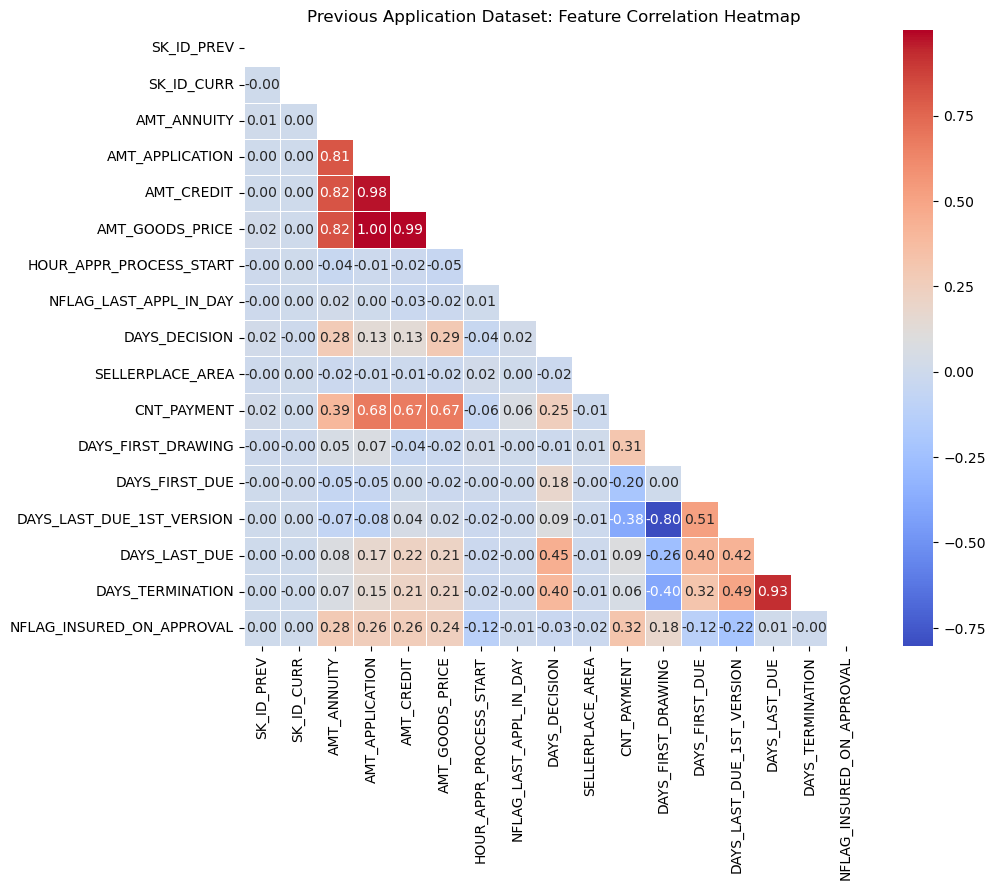

  Variables with Correlation ABOVE 65%
AMT_GOODS_PRICE & AMT_APPLICATION
→ Correlation: 1.00 (positive)

AMT_GOODS_PRICE & AMT_CREDIT
→ Correlation: 0.99 (positive)

AMT_CREDIT & AMT_APPLICATION
→ Correlation: 0.98 (positive)

DAYS_TERMINATION & DAYS_LAST_DUE
→ Correlation: 0.93 (positive)

AMT_GOODS_PRICE & AMT_ANNUITY
→ Correlation: 0.82 (positive)

AMT_CREDIT & AMT_ANNUITY
→ Correlation: 0.82 (positive)

AMT_APPLICATION & AMT_ANNUITY
→ Correlation: 0.81 (positive)

CNT_PAYMENT & AMT_APPLICATION
→ Correlation: 0.68 (positive)

CNT_PAYMENT & AMT_CREDIT
→ Correlation: 0.67 (positive)

CNT_PAYMENT & AMT_GOODS_PRICE
→ Correlation: 0.67 (positive)

DAYS_LAST_DUE_1ST_VERSION & DAYS_FIRST_DRAWING
→ Correlation: -0.80 (negative)

  Total highly correlated pairs found: 11


In [14]:
# Previous Application Correlation matrix
corr = prev_df.select_dtypes(include='number').corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Previous Application Dataset: Feature Correlation Heatmap")
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

Handle Multicollinearity
Group 1: AMT_CREDIT, AMT_APPLICATION, AMT_GOODS_PRICE (0.98–1.00)
These are nearly identical so we decide to drop two and keep one. AMT_CREDIT is usually the most meaningful for credit risk modeling since it's the actual loan amount granted. Drop AMT_APPLICATION and AMT_GOODS_PRICE.

Group 2: AMT_ANNUITY + CNT_PAYMENT (0.67–0.82)
These correlate with the AMT group above. Since we have already kept AMT_CREDIT, we decide to drop AMT_ANNUITY and engineer a new feature like AMT_ANNUITY / AMT_CREDIT (annuity rate), which captures more information than either alone.

Group 3: DAYS_TERMINATION & DAYS_LAST_DUE (0.93)
Keep one — DAYS_LAST_DUE is more interpretable. Drop DAYS_TERMINATION.

Group 4: DAYS_LAST_DUE_1ST_VERSION & DAYS_FIRST_DRAWING (-0.80)
Strong negative correlation is still multicollinearity. Consider dropping DAYS_FIRST_DRAWING or engineering a duration feature like DAYS_LAST_DUE_1ST_VERSION - DAYS_FIRST_DRAWING to capture the loan term span.

In [15]:
# Feature Engineering
# Group 2 
prev_df["AMT_ANNUITY_RATE"]=prev_df["AMT_ANNUITY"]/prev_df["AMT_CREDIT"]

# Group 3 
prev_df['LOAN_TERM_SPAN'] = prev_df['DAYS_LAST_DUE_1ST_VERSION'] - prev_df['DAYS_FIRST_DRAWING']

In [16]:
# Drop features
prev_df.drop(columns=["AMT_APPLICATION", "AMT_GOODS_PRICE"], inplace=True)
prev_df.drop(columns=["AMT_ANNUITY"], inplace=True)
prev_df = prev_df.drop(columns=['DAYS_LAST_DUE_1ST_VERSION', 'DAYS_FIRST_DRAWING'], errors='ignore')

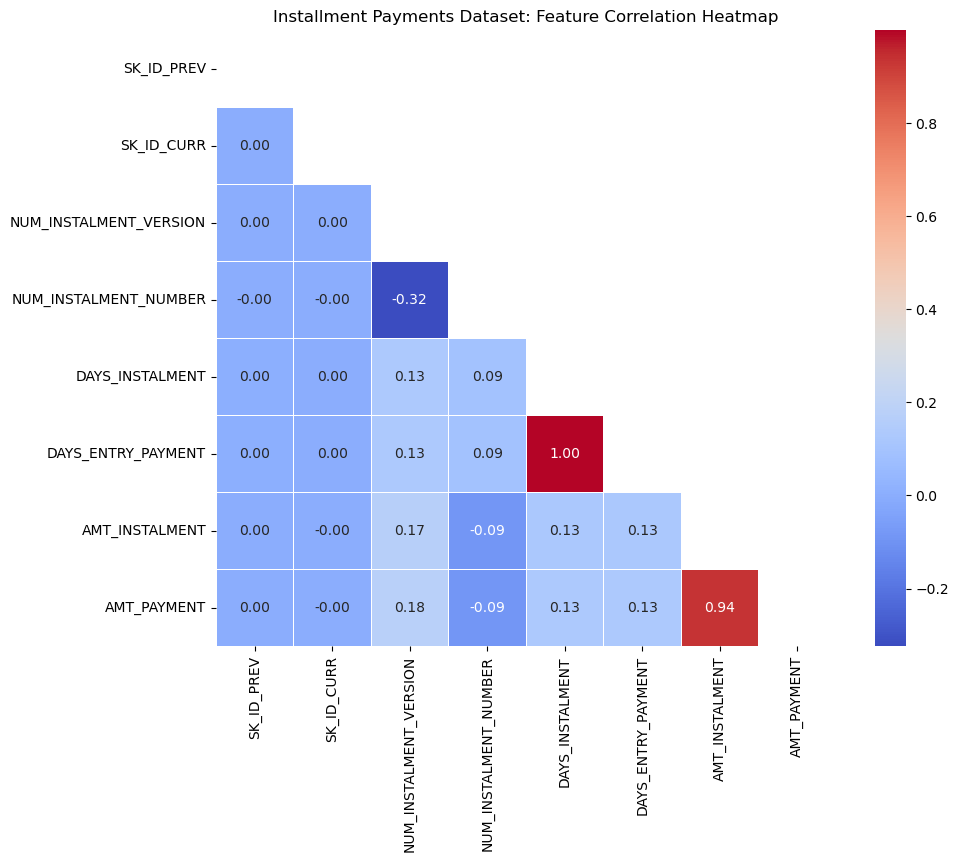

  Variables with Correlation ABOVE 65%
DAYS_ENTRY_PAYMENT & DAYS_INSTALMENT
→ Correlation: 1.00 (positive)

AMT_PAYMENT & AMT_INSTALMENT
→ Correlation: 0.94 (positive)

  Total highly correlated pairs found: 2


In [17]:
# Installments payments Correlation matrix
corr = inst_df.select_dtypes(include='number').corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Installment Payments Dataset: Feature Correlation Heatmap")
plt.show()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

After looking at the correlation matrix, we see that DAYS_ENTRY_PAYMENT and DAYS_INSTALMENT are 100% correlated. So we decide to enginner a new feature DAYS_PAYMENT_DELAY and drop the two features. We believe this new feature is good at capturing how late or early the customer paid. If there are alot of late payments, then this suggests high risk of Default.

As for AMT_PAYMENT and AMT_INSTALMENT which are 94% correlated. We decide to engineer two new features PAYMENT_RATIO and PAYMENT_DIFF to capture how much of the required payment was actually paid. Then we drop AMT_PAYMENT and AMT_INSTALMENT.

In [18]:
# Feature engineering
inst_df['DAYS_PAYMENT_DELAY'] = inst_df['DAYS_ENTRY_PAYMENT'] - inst_df['DAYS_INSTALMENT']
inst_df['PAYMENT_RATIO'] = inst_df['AMT_PAYMENT'] / (inst_df['AMT_INSTALMENT'] + 1)
inst_df['PAYMENT_DIFF']  = inst_df['AMT_PAYMENT'] - inst_df['AMT_INSTALMENT']

In [19]:
# Drop features
inst_df.drop(columns=['DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT'], inplace=True)
inst_df.drop(columns=['AMT_PAYMENT', 'AMT_INSTALMENT'], inplace=True)

## Merging Datasets and Aggregating

In [20]:
# Bureau Dataset
bureau_agg = bureau_df.groupby('SK_ID_CURR').agg(

    # --- Credit Count & Activity ---
    BUREAU_CREDIT_COUNT          = ('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT          = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT          = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),

    # --- Overdue ---
    BUREAU_OVERDUE_MEAN          = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_OVERDUE_MAX           = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_OVERDUE_SUM           = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),

    # --- Debt Utilization (replaces AMT_CREDIT_SUM & AMT_CREDIT_SUM_DEBT) ---
    BUREAU_DEBT_UTIL_MEAN        = ('DEBT_UTILIZATION', 'mean'),
    BUREAU_DEBT_UTIL_MAX         = ('DEBT_UTILIZATION', 'max'),

    # --- Credit Duration (replaces DAYS_CREDIT & DAYS_ENDDATE_FACT) ---
    BUREAU_DURATION_MEAN         = ('CREDIT_DURATION', 'mean'),
    BUREAU_DURATION_MAX          = ('CREDIT_DURATION', 'max'),

    # --- Credit Remaining (replaces AMT_CREDIT_SUM & AMT_CREDIT_SUM_DEBT) ---
    BUREAU_CREDIT_REMAINING_MEAN = ('CREDIT_REMAINING', 'mean'),
    BUREAU_CREDIT_REMAINING_SUM  = ('CREDIT_REMAINING', 'sum'),

    # --- Prolongations ---
    BUREAU_PROLONG_SUM           = ('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_PROLONG_MAX           = ('CNT_CREDIT_PROLONG', 'max'),

    # --- Days Since Close to Update (replaces DAYS_ENDDATE_FACT & DAYS_CREDIT_UPDATE) ---
    BUREAU_DAYS_SINCE_CLOSE_MEAN = ('DAYS_SINCE_CLOSE_TO_UPDATE', 'mean'),

    # --- Days Since Open to Update (replaces DAYS_CREDIT & DAYS_CREDIT_UPDATE) ---
    BUREAU_DAYS_SINCE_OPEN_MEAN  = ('DAYS_SINCE_OPEN_TO_UPDATE', 'mean'),

).reset_index()

In [21]:
# Aggregate prev_df
prev_agg = prev_df.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT         = ('SK_ID_PREV', 'count'),
    PREV_APPROVAL_RATE     = ('NAME_CONTRACT_STATUS',
                              lambda x: (x == 'Approved').sum() / len(x)),
    PREV_DOMINANT_STATUS   = ('NAME_CONTRACT_STATUS',
                              lambda x: x.value_counts().index[0]),
    PREV_AVG_DAYS_LAST_DUE = ('DAYS_LAST_DUE', 'mean')
).reset_index()

# Verify it — should print True
print(prev_agg['SK_ID_CURR'].is_unique)

True


In [22]:
inst_with_prev = inst_df.merge(
    prev_df[['SK_ID_PREV','CODE_REJECT_REASON','NAME_YIELD_GROUP','NAME_CONTRACT_STATUS',
             'DAYS_LAST_DUE']],
    on='SK_ID_PREV',
    how='left'
)

inst_with_prev.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_PAYMENT_DELAY', 'PAYMENT_RATIO',
       'PAYMENT_DIFF', 'CODE_REJECT_REASON', 'NAME_YIELD_GROUP',
       'NAME_CONTRACT_STATUS', 'DAYS_LAST_DUE'],
      dtype='object')

In [23]:
# Aggregate installment_table up to SK_ID_CURR level
inst_agg = inst_with_prev.groupby('SK_ID_CURR').agg(
    INST_NUM_PREV_LOANS     = ('SK_ID_PREV', 'nunique'),
    INST_MAX_VERSION        = ('NUM_INSTALMENT_VERSION', 'max'),
    INST_MAX_NUMBER         = ('NUM_INSTALMENT_NUMBER', 'max'),
    INST_AVG_DELAY          = ('DAYS_PAYMENT_DELAY', 'mean'),
    INST_MAX_DELAY          = ('DAYS_PAYMENT_DELAY', 'max'),
    INST_MIN_DELAY          = ('DAYS_PAYMENT_DELAY', 'min'),
    INST_NUM_LATE           = ('DAYS_PAYMENT_DELAY', lambda x: (x > 0).sum()),
    INST_NUM_EARLY          = ('DAYS_PAYMENT_DELAY', lambda x: (x < 0).sum()),
    INST_AVG_PAYMENT_RATIO  = ('PAYMENT_RATIO', 'mean'),
    INST_MIN_PAYMENT_RATIO  = ('PAYMENT_RATIO', 'min'),
    INST_NUM_UNDERPAID      = ('PAYMENT_RATIO', lambda x: (x < 1).sum()),
    INST_AVG_PAYMENT_DIFF   = ('PAYMENT_DIFF', 'mean'),
    INST_MIN_PAYMENT_DIFF   = ('PAYMENT_DIFF', 'min'),
    INST_MAX_PAYMENT_DIFF   = ('PAYMENT_DIFF', 'max'),
    INST_NUM_RECORDS        = ('SK_ID_PREV', 'count'),
    PREV_REJECT_COUNT       = ('CODE_REJECT_REASON', lambda x: (x != 'XAP').sum()),
    PREV_APPROVED_COUNT     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELLED_COUNT    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_APPROVAL_RATE      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').mean()),
    PREV_YIELD_GROUP_MODE   = ('NAME_YIELD_GROUP', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),  # fixed
    PREV_DAYS_LAST_DUE_MAX  = ('DAYS_LAST_DUE', 'max')
).reset_index()

inst_agg.columns

Index(['SK_ID_CURR', 'INST_NUM_PREV_LOANS', 'INST_MAX_VERSION',
       'INST_MAX_NUMBER', 'INST_AVG_DELAY', 'INST_MAX_DELAY', 'INST_MIN_DELAY',
       'INST_NUM_LATE', 'INST_NUM_EARLY', 'INST_AVG_PAYMENT_RATIO',
       'INST_MIN_PAYMENT_RATIO', 'INST_NUM_UNDERPAID', 'INST_AVG_PAYMENT_DIFF',
       'INST_MIN_PAYMENT_DIFF', 'INST_MAX_PAYMENT_DIFF', 'INST_NUM_RECORDS',
       'PREV_REJECT_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
       'PREV_CANCELLED_COUNT', 'PREV_APPROVAL_RATE', 'PREV_YIELD_GROUP_MODE',
       'PREV_DAYS_LAST_DUE_MAX'],
      dtype='object')

In [24]:
# All tables are at SK_ID_CURR level — merge into main table
merged_main_bureau = application_df.merge(bureau_agg,on='SK_ID_CURR', how='left')
merged_df = merged_main_bureau.merge(inst_agg,on='SK_ID_CURR', how='left')

merged_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_EDUCATION_TYPE', 'ANNUITY_INCOME_RATIO',
       'LOAN_INCOME_RATIO', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_EMPLOYED', 'DAYS_BIRTH',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT_W_CITY', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY', 'FLAG_OWN_CAR',
       'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'CODE_GENDER', 'BUREAU_CREDIT_COUNT', 'BUREAU_ACTIVE_COUNT',
       'BUREAU_CLOSED_COUNT', 'BUREAU_OVERDUE_MEAN', 'BUREAU_OVERDUE_MAX',
       'BUREAU_OVERDUE_SUM', 'BUREAU_DEBT_UTIL_MEAN', 'BUREAU_DEBT_UTIL_MAX',
       'BUREAU_DURATION_MEAN', 'BUREAU_DURATION_MAX',
       'BUREAU_CREDIT_REMAINING_MEAN', 'BUREAU_CREDIT_REMAINING_SUM',
       'BUREAU_PROLONG_SUM', 'BUREAU_PROLONG_MAX',
       'BUREAU_DAYS_SINCE_CLOSE_MEAN', 'BUREAU_DAYS_SINCE_OPEN_MEAN',
       'INST_NUM_PREV_LOANS', 'INST_

### Aggregation Strategy

Before aggregating each supplementary table to the applicant (`SK_ID_CURR`) level, we chose aggregation functions deliberately based on what each statistic captures:

- **MAX** — When the worst case matters (risk indicators). A single catastrophic event (e.g., one severely overdue payment) is more predictive of default than an average.
- **MEAN** — When typical behavior matters. The average captures consistent patterns across all observations and is more robust to isolated extremes.
- **MIN** — When the most recent or best case matters. For days-based features, `MIN` gives the most recent event since days are stored as negative integers (closer to 0 = more recent).
- **SUM** — When total exposure matters. Cumulative totals capture overall financial burden regardless of how many individual loans exist.
- **COUNT / NUNIQUE** — When frequency or diversity matters. How many times something happened or how many distinct items are involved.


In [25]:
# Export csv files to create dashboard in PowerBI
import sqlite3

conn = sqlite3.connect('loan_default.db')

application_df.to_sql('application_train',    conn, if_exists='replace', index=False)
bureau_agg.to_sql('bureau',                   conn, if_exists='replace', index=False)
inst_agg.to_sql('installments_payments',      conn, if_exists='replace', index=False)
prev_agg.to_sql('previous_application',        conn, if_exists='replace', index=False)

conn.close()

print("4 tables saved to loan_default.db")

4 tables saved to loan_default.db


## Handling Multicollinearity in Merged Dataset

In [26]:
# Correlation matrix
merge_corr = merged_df.select_dtypes(include='number').corr()

# SUMMARY — Highly Correlated Pairs (above 65%)
threshold = 0.65

# Get lower triangle only to avoid duplicates
lower_triangle = merge_corr.where(np.tril(np.ones(merge_corr.shape), k=-1).astype(bool))

# Find pairs above threshold
high_corr_pairs = (
    lower_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2', 0: 'Correlation'})
)

# Filter by absolute correlation above threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False)

# Print summary
print("=" * 55)
print(f"  Variables with Correlation ABOVE {int(threshold*100)}%")
print("=" * 55)
if high_corr_pairs.empty:
    print("No variables are highly correlated above 65%!")
else:
    for _, row in high_corr_pairs.iterrows():
        direction = "positive" if row['Correlation'] > 0 else "negative"
        print(f"{row['Variable 1']} & {row['Variable 2']}")
        print(f"→ Correlation: {row['Correlation']:.2f} ({direction})")
        print()
print("=" * 55)
print(f"  Total highly correlated pairs found: {len(high_corr_pairs)}")
print("=" * 55)

  Variables with Correlation ABOVE 65%
INST_NUM_RECORDS & INST_NUM_UNDERPAID
→ Correlation: 1.00 (positive)

BUREAU_PROLONG_MAX & BUREAU_PROLONG_SUM
→ Correlation: 0.99 (positive)

BUREAU_CLOSED_COUNT & BUREAU_CREDIT_COUNT
→ Correlation: 0.92 (positive)

INST_NUM_RECORDS & INST_NUM_EARLY
→ Correlation: 0.89 (positive)

INST_NUM_UNDERPAID & INST_NUM_EARLY
→ Correlation: 0.89 (positive)

PREV_APPROVED_COUNT & INST_NUM_RECORDS
→ Correlation: 0.89 (positive)

PREV_APPROVED_COUNT & INST_NUM_UNDERPAID
→ Correlation: 0.89 (positive)

PREV_APPROVED_COUNT & INST_NUM_EARLY
→ Correlation: 0.85 (positive)

BUREAU_DEBT_UTIL_MAX & BUREAU_DEBT_UTIL_MEAN
→ Correlation: 0.81 (positive)

INST_NUM_UNDERPAID & INST_MAX_NUMBER
→ Correlation: 0.79 (positive)

INST_NUM_RECORDS & INST_MAX_NUMBER
→ Correlation: 0.79 (positive)

LOAN_INCOME_RATIO & ANNUITY_INCOME_RATIO
→ Correlation: 0.79 (positive)

INST_NUM_EARLY & INST_NUM_PREV_LOANS
→ Correlation: 0.78 (positive)

BUREAU_DURATION_MAX & BUREAU_DURATION_MEAN


## Multicollinearity Analysis — Merged Dataset

After examining the correlation matrix on the merged dataset, we identified 15 highly 
correlated pairs above our 65% threshold. Here is what we decided to do:

**Max/Mean Redundancy**
For features where both the max and mean of the same metric were included, we decided 
to keep the mean and drop the max. The mean provides a more stable and representative 
summary across all credit records, while the max is more sensitive to outliers and adds 
redundant information.
- BUREAU_DURATION_MAX & BUREAU_DURATION_MEAN (0.77) → drop BUREAU_DURATION_MAX
- BUREAU_OVERDUE_MAX & BUREAU_OVERDUE_MEAN (0.76) → drop BUREAU_OVERDUE_MAX
- BUREAU_PROLONG_MAX & BUREAU_PROLONG_SUM (0.99) → drop BUREAU_PROLONG_MAX
- BUREAU_CREDIT_REMAINING_SUM & BUREAU_CREDIT_REMAINING_MEAN (0.70) → drop BUREAU_CREDIT_REMAINING_SUM

**Credit Count Redundancy**
BUREAU_CLOSED_COUNT and BUREAU_ACTIVE_COUNT are both highly correlated with 
BUREAU_CREDIT_COUNT (0.92 and 0.70 respectively). Since we already engineered 
BUREAU_ACTIVE_RATIO which captures the relationship between active credits and 
total credits, keeping the raw counts adds redundant information.
- Drop BUREAU_CLOSED_COUNT
- Drop BUREAU_ACTIVE_COUNT

**Installment Count Cluster**
INST_NUM_RECORDS, INST_NUM_UNDERPAID, and INST_NUM_EARLY are all highly correlated 
with each other (0.91-1.00) and with PREV_APPROVED_COUNT (0.89-0.91). These features 
are all proxies for the same underlying signal — how many loans the applicant has had. 
We keep INST_NUM_RECORDS as the base count and drop the others since INST_UNDERPAID_RATE 
and INST_EARLY_RATE already capture payment behavior more cleanly as ratios.
- Drop INST_NUM_UNDERPAID
- Drop INST_NUM_EARLY
- Drop PREV_APPROVED_COUNT

**LOAN_INCOME_RATIO & ANNUITY_INCOME_RATIO (0.79)**
Although these two features are correlated at 0.79, we decided to keep both because 
they capture meaningfully different aspects of financial burden. LOAN_INCOME_RATIO 
reflects the total loan size relative to income, while ANNUITY_INCOME_RATIO reflects 
the monthly repayment burden relative to income. We believe both signals are important 
for predicting default risk.

**PREV_APPROVAL_RATE & PREV_REJECT_COUNT (-0.68)**
These two features are mathematically inverse — a high approval rate naturally means 
a low reject count. We keep PREV_APPROVAL_RATE and drop PREV_REJECT_COUNT because 
a rate is more interpretable and consistent across applicants with different numbers 
of past applications.
- Drop PREV_REJECT_COUNT

**BUREAU_DAYS_SINCE_OPEN_MEAN & BUREAU_DAYS_SINCE_CLOSE_MEAN (0.67)**
Both features measure the recency of credit activity. We keep BUREAU_DAYS_SINCE_OPEN_MEAN 
and drop BUREAU_DAYS_SINCE_CLOSE_MEAN because the open date captures the full length 
of the applicant's credit history, which is a stronger signal for creditworthiness.
- Drop BUREAU_DAYS_SINCE_CLOSE_MEAN

In [27]:
cols_to_drop = [
    # BUREAU — Max/Mean redundancy (keep mean, drop max)
    'BUREAU_DURATION_MAX',
    'BUREAU_OVERDUE_MAX',
    'BUREAU_PROLONG_MAX',
    'BUREAU_CREDIT_REMAINING_SUM',

    # BUREAU — Count redundancy (BUREAU_ACTIVE_RATIO already captures this)
    'BUREAU_CLOSED_COUNT',
    'BUREAU_ACTIVE_COUNT',

    # INST — Installment count cluster (keep rates instead of raw counts)
    'INST_NUM_UNDERPAID',
    'INST_NUM_EARLY',

    # PREV — Mathematically inverse to PREV_APPROVAL_RATE
    'PREV_APPROVED_COUNT',
    'PREV_REJECT_COUNT',

    # BUREAU — Recency redundancy (keep BUREAU_DAYS_SINCE_OPEN_MEAN)
    'BUREAU_DAYS_SINCE_CLOSE_MEAN',
]

# Only drop columns that actually exist in merged_df
existing_cols = [col for col in cols_to_drop if col in merged_df.columns]
missing_cols_drop = [col for col in cols_to_drop if col not in merged_df.columns]

if missing_cols_drop:
    print(f"These columns don't exist and will be skipped: {missing_cols_drop}")

merged_df.drop(columns=existing_cols, inplace=True)
print(f"Dropped {len(existing_cols)} columns")
print(f"Remaining shape: {merged_df.shape}")

Dropped 11 columns
Remaining shape: (307511, 50)


In [28]:
merged_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_EDUCATION_TYPE', 'ANNUITY_INCOME_RATIO',
       'LOAN_INCOME_RATIO', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_EMPLOYED', 'DAYS_BIRTH',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT_W_CITY', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY', 'FLAG_OWN_CAR',
       'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'CODE_GENDER', 'BUREAU_CREDIT_COUNT', 'BUREAU_OVERDUE_MEAN',
       'BUREAU_OVERDUE_SUM', 'BUREAU_DEBT_UTIL_MEAN', 'BUREAU_DEBT_UTIL_MAX',
       'BUREAU_DURATION_MEAN', 'BUREAU_CREDIT_REMAINING_MEAN',
       'BUREAU_PROLONG_SUM', 'BUREAU_DAYS_SINCE_OPEN_MEAN',
       'INST_NUM_PREV_LOANS', 'INST_MAX_VERSION', 'INST_MAX_NUMBER',
       'INST_AVG_DELAY', 'INST_MAX_DELAY', 'INST_MIN_DELAY', 'INST_NUM_LATE',
       'INST_AVG_PAYMENT_RATIO', 'INST_MIN_PAYMENT_RATIO',
       'INST_AVG_PAYMENT_DI

## Train/Test Split
Before building our model, we decide to do a test split on our data to avoid overfitting and data leakage. we will do a stratified test split on our data because our data consists of 8% default compared to 92% repay the loan which causes an imbalance dataset. We will take 80% of our data for training, 20%  for testing.

In [29]:
# Drop ID column — it carries no predictive signal
X = merged_df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = merged_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reset indices so they align correctly
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True).round(3)}")


Train size: (246008, 48), Test size: (61503, 48)
Train target distribution:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## Preprocess
We wil begin by identifying missing data and classify missing data. Then we will handle missing data, handle outliers and encode variables.

In [30]:
# Checking for Missing values
X_train.isnull().sum()

NAME_EDUCATION_TYPE                 0
ANNUITY_INCOME_RATIO               10
LOAN_INCOME_RATIO                   0
DAYS_REGISTRATION                   0
DAYS_ID_PUBLISH                     0
DAYS_LAST_PHONE_CHANGE              1
AMT_REQ_CREDIT_BUREAU_YEAR      33244
DEF_60_CNT_SOCIAL_CIRCLE          811
DAYS_EMPLOYED                       0
DAYS_BIRTH                          0
CNT_FAM_MEMBERS                     2
REGION_RATING_CLIENT_W_CITY         0
EXT_SOURCE_2                      531
EXT_SOURCE_3                    48805
NAME_CONTRACT_TYPE                  0
FLAG_OWN_REALTY                     0
FLAG_OWN_CAR                        0
NAME_INCOME_TYPE                    0
NAME_FAMILY_STATUS                  0
NAME_HOUSING_TYPE                   0
CODE_GENDER                         0
BUREAU_CREDIT_COUNT             35244
BUREAU_OVERDUE_MEAN             35244
BUREAU_OVERDUE_SUM              35244
BUREAU_DEBT_UTIL_MEAN           41153
BUREAU_DEBT_UTIL_MAX            41153
BUREAU_DURAT

In [31]:
# Step 1: Create binary missingness indicators on BOTH train and test
missing_cols = [col for col in X_train.columns if X_train[col].isnull().any()]

for col in missing_cols:
    X_train[f'{col}_MISSING'] = X_train[col].isnull().astype(int)
    X_test[f'{col}_MISSING']  = X_test[col].isnull().astype(int)  # don't forget test!

# Step 2: Correlate missingness with TARGET
missingness_indicators = [f'{col}_MISSING' for col in missing_cols]
correlation_with_missing = X_train[missingness_indicators].corrwith(y_train)
print("Correlation of missingness with TARGET:")
print(correlation_with_missing.sort_values(ascending=False))

# Step 3: Classify each column into MAR, MCAR, or MNAR
mar_features  = []
mcar_features = []
mnar_features = []

MIN_SAMPLE_SIZE = 30

for col in missing_cols:
    missing_mask = X_train[col].isnull()
    corr = abs(correlation_with_missing[f'{col}_MISSING'])

    group_missing = X_train.loc[missing_mask, 'ANNUITY_INCOME_RATIO'].dropna()
    group_present = X_train.loc[~missing_mask, 'ANNUITY_INCOME_RATIO'].dropna()

    # Too few samples — classify by correlation alone
    if len(group_missing) < MIN_SAMPLE_SIZE or len(group_present) < MIN_SAMPLE_SIZE:
        if corr > 0.05:
            mnar_features.append(col)
        else:
            mcar_features.append(col)
        continue

    t_stat, p_value = stats.ttest_ind(group_missing, group_present, equal_var=False)

    if corr > 0.05:
        mnar_features.append(col)
        print(f"{col}: MNAR likely  (corr={corr:.4f})")
    elif p_value < 0.05:
        mar_features.append(col)
        print(f"{col}: MAR likely   (p={p_value:.4f})")
    else:
        mcar_features.append(col)
        print(f"{col}: MCAR likely  (p={p_value:.4f})")

# Step 4: Confirm lists are populated before imputing
print("\n--- Summary ---")
print(f"MAR  ({len(mar_features)}):  {mar_features}")
print(f"MCAR ({len(mcar_features)}): {mcar_features}")
print(f"MNAR ({len(mnar_features)}): {mnar_features}")

Correlation of missingness with TARGET:
BUREAU_DURATION_MEAN_MISSING            0.051375
AMT_REQ_CREDIT_BUREAU_YEAR_MISSING      0.032877
BUREAU_CREDIT_COUNT_MISSING             0.030742
BUREAU_OVERDUE_MEAN_MISSING             0.030742
BUREAU_OVERDUE_SUM_MISSING              0.030742
BUREAU_PROLONG_SUM_MISSING              0.030742
BUREAU_DAYS_SINCE_OPEN_MEAN_MISSING     0.030742
BUREAU_DEBT_UTIL_MEAN_MISSING           0.025417
BUREAU_DEBT_UTIL_MAX_MISSING            0.025417
BUREAU_CREDIT_REMAINING_MEAN_MISSING    0.025417
EXT_SOURCE_3_MISSING                    0.022002
DAYS_LAST_PHONE_CHANGE_MISSING         -0.000597
EXT_SOURCE_2_MISSING                   -0.000600
CNT_FAM_MEMBERS_MISSING                -0.000845
ANNUITY_INCOME_RATIO_MISSING           -0.001889
DEF_60_CNT_SOCIAL_CIRCLE_MISSING       -0.008713
PREV_DAYS_LAST_DUE_MAX_MISSING         -0.016422
INST_NUM_PREV_LOANS_MISSING            -0.017889
INST_MAX_NUMBER_MISSING                -0.017889
PREV_YIELD_GROUP_MODE_MISSING

### Summary of Missing Data
This allows us to identify what the missing values most likely are.  We can see that there are mostly MAR data that can be Imputed using an iterative imputer.  There are very few MCAR and MNAR values that will be median imputed or flagged then imputed, respectively.

### Missingness Classification Approach

We classify each missing feature into one of three categories:

- **MNAR (Missing Not At Random):** Missingness correlates with the target variable (|correlation| > 0.05). The data is likely missing for a reason related to the outcome — e.g., applicants who default may be more likely to withhold information. Binary missingness indicators are created to preserve this signal before imputation.
- **MAR (Missing At Random):** Missingness does not correlate with the target, but a statistically significant difference exists between distributions when the feature is present vs. absent (Welch's t-test, p < 0.05). These features are imputed using **IterativeImputer**, which uses other features to estimate missing values.
- **MCAR (Missing Completely At Random):** Neither condition above holds. These features are imputed using **median imputation** via `SimpleImputer`.

All imputers are fit **only on the training set** to prevent data leakage.


In [32]:
# Check for any remaining string columns in missingness feature lists
# (String columns cannot be imputed numerically and must be excluded)
for feature_list, list_name in [(mar_features, 'mar_features'),
                                  (mcar_features, 'mcar_features'),
                                  (mnar_features, 'mnar_features')]:
    string_cols = X_train[feature_list].select_dtypes(include=['object']).columns.tolist()
    if string_cols:
        print(f"{list_name} has string columns that will be excluded: {string_cols}")
    else:
        print(f"{list_name}: OK (no string columns)")

# Remove string columns from feature lists before imputation
def remove_string_cols(feature_list, df):
    return [col for col in feature_list
            if col in df.columns
            and df[col].dtype != 'object']

mar_features  = remove_string_cols(mar_features, X_train)
mcar_features = remove_string_cols(mcar_features, X_train)
mnar_features = remove_string_cols(mnar_features, X_train)


mar_features has string columns that will be excluded: ['PREV_YIELD_GROUP_MODE']
mcar_features: OK (no string columns)
mnar_features: OK (no string columns)


In [33]:
# Verify feature list sizes after string column removal
print(f"MAR  features ({len(mar_features)}):  {mar_features[:5]}{'...' if len(mar_features) > 5 else ''}")
print(f"MCAR features ({len(mcar_features)}): {mcar_features}")
print(f"MNAR features ({len(mnar_features)}): {mnar_features}")


MAR  features (28):  ['AMT_REQ_CREDIT_BUREAU_YEAR', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_3', 'BUREAU_CREDIT_COUNT', 'BUREAU_OVERDUE_MEAN']...
MCAR features (4): ['ANNUITY_INCOME_RATIO', 'DAYS_LAST_PHONE_CHANGE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_2']
MNAR features (1): ['BUREAU_DURATION_MEAN']


In [34]:
# MAR: Iterative Imputer
iter_imputer = IterativeImputer(random_state=42)
X_train[mar_features] = iter_imputer.fit_transform(X_train[mar_features])
X_test[mar_features]  = iter_imputer.transform(X_test[mar_features])

# MCAR: Simple Imputer (median)
simple_imputer = SimpleImputer(strategy='median')
X_train[mcar_features] = simple_imputer.fit_transform(X_train[mcar_features])
X_test[mcar_features]  = simple_imputer.transform(X_test[mcar_features])

# MNAR: Simple Imputer (median) — _MISSING indicators already capture the signal
if mnar_features:
    mnar_imputer = SimpleImputer(strategy='median')
    X_train[mnar_features] = mnar_imputer.fit_transform(X_train[mnar_features])
    X_test[mnar_features]  = mnar_imputer.transform(X_test[mnar_features])

# Verify no missing values remain
print("X_train missing:", X_train.isnull().sum().sum())
print("X_test missing: ", X_test.isnull().sum().sum())

X_train missing: 12686
X_test missing:  3182


### Handling the PREV_YIELD_GROUP_MODE Column

After imputation, we inspect the `PREV_YIELD_GROUP_MODE` column, which was flagged as MNAR. Because it is a categorical feature, it was excluded from numeric imputation. We verify its contents and determine whether it can be retained or must be dropped.


In [35]:
with pd.option_context('display.max_rows', None):
    display(X_train['PREV_YIELD_GROUP_MODE'].isnull().sum())

np.int64(12686)

In [36]:
# Verify flag is all 1s
print(X_train['PREV_YIELD_GROUP_MODE'].value_counts())

# Drop the useless all-NaN column — errors='ignore' prevents error if already dropped
X_train = X_train.drop(columns=['PREV_YIELD_GROUP_MODE'], errors='ignore')
X_test  = X_test.drop(columns=['PREV_YIELD_GROUP_MODE'], errors='ignore')

# Remove from mnar_features list
mnar_features = [f for f in mnar_features if f != 'PREV_YIELD_GROUP_MODE']

# Verify
print("PREV_YIELD_GROUP_MODE in X_train:", 'PREV_YIELD_GROUP_MODE' in X_train.columns)
print("mnar_features:", mnar_features)

PREV_YIELD_GROUP_MODE
middle        63724
high          62119
low_normal    51848
XNA           32910
low_action    20894
Unknown        1827
Name: count, dtype: int64
PREV_YIELD_GROUP_MODE in X_train: False
mnar_features: ['BUREAU_DURATION_MEAN']


### Decision: Drop `PREV_YIELD_GROUP_MODE`

`PREV_YIELD_GROUP_MODE` was found to contain only `NaN` values after aggregation across all applicants, indicating that this feature carries no usable signal in the merged dataset. It was removed from the feature set to avoid introducing a column of entirely missing values into the model.


In [37]:
# Dealing with Outliers
def get_iqr_bounds(df, cols):
    bounds = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        bounds[col] = {
            'lower': Q1 - 1.5 * IQR,
            'upper': Q3 + 1.5 * IQR
        }
    return bounds

def apply_iqr_clip(df, bounds):
    df = df.copy()
    for col, b in bounds.items():
        df[col] = df[col].clip(lower=b['lower'], upper=b['upper'])
    return df

# Numeric columns only
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

# Step 1: Learn bounds from X_train ONLY
bounds = get_iqr_bounds(X_train, numeric_cols)

# Step 2: Apply to both train and test
X_train = apply_iqr_clip(X_train, bounds)
X_test  = apply_iqr_clip(X_test, bounds)

# Verify
print("Outlier clipping done")
print(f"Columns processed: {len(numeric_cols)}")

Outlier clipping done
Columns processed: 73


In [38]:
# Encoding 
# Defragment first
X_train = X_train.copy()
X_test  = X_test.copy()

# Step 1 — Ordinal mapping
X_train["EDUCATION_TYPE"] = X_train["NAME_EDUCATION_TYPE"].map({
    "Lower secondary": 0,
    "Secondary / secondary special": 1,
    "Secondary / secondary specia": 1,
    "Incomplete higher": 2,
    "Higher education": 3,
    "Academic degree": 4
})
X_train["CONTRACT_TYPE"] = X_train["NAME_CONTRACT_TYPE"].map({"Revolving loans": 0, "Cash loans": 1})
X_train["OWN_REALTY"] = X_train["FLAG_OWN_REALTY"].map({"N": 0, "Y": 1})
X_train["OWN_CAR"] = X_train["FLAG_OWN_CAR"].map({"N": 0, "Y": 1})

# Apply same mapping to X_test
X_test["EDUCATION_TYPE"] = X_test["NAME_EDUCATION_TYPE"].map({
    "Lower secondary": 0,
    "Secondary / secondary special": 1,
    "Incomplete higher": 2,
    "Higher education": 3,
    "Academic degree": 4
})
X_test["CONTRACT_TYPE"] = X_test["NAME_CONTRACT_TYPE"].map({"Revolving loans": 0, "Cash loans": 1})
X_test["OWN_REALTY"] = X_test["FLAG_OWN_REALTY"].map({"N": 0, "Y": 1})
X_test["OWN_CAR"] = X_test["FLAG_OWN_CAR"].map({"N": 0, "Y": 1})

# Step 2 — Ordinal/binary encoded df (one creation only)
encoded_df_1 = pd.DataFrame({
    "CONTRACT_TYPE": X_train["CONTRACT_TYPE"],
    "OWN_REALTY": X_train["OWN_REALTY"],
    "OWN_CAR": X_train["OWN_CAR"],
    "EDUCATION_TYPE": X_train["EDUCATION_TYPE"]
})
encoded_df_1_test = pd.DataFrame({
    "CONTRACT_TYPE": X_test["CONTRACT_TYPE"],
    "OWN_REALTY": X_test["OWN_REALTY"],
    "OWN_CAR": X_test["OWN_CAR"],
    "EDUCATION_TYPE": X_test["EDUCATION_TYPE"]
})

# Step 3 — Nominal one-hot encoding
nominal_cols = ['NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'CODE_GENDER']
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit on X_train only
encoded_df_2 = pd.DataFrame(
    encoder.fit_transform(X_train[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_train.index
)

# Transform X_test with same encoder
encoded_df_2_test = pd.DataFrame(
    encoder.transform(X_test[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_test.index
)

# Step 4 — Drop original categorical columns
cols_to_drop = [
    'NAME_EDUCATION_TYPE', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY', 'FLAG_OWN_CAR',
    'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'CODE_GENDER',
    'EDUCATION_TYPE', 'CONTRACT_TYPE', 'OWN_REALTY', 'OWN_CAR'
]
X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean = X_test.drop(columns=cols_to_drop)

# Step 5 — Select numeric columns
num_cols_train = X_train_clean.select_dtypes(include=['number'])
num_cols_test = X_test_clean.select_dtypes(include=['number'])

# Step 6 — Combine all encoded parts
X_train_final = pd.concat([num_cols_train, encoded_df_1, encoded_df_2], axis=1)
X_test_final = pd.concat([num_cols_test, encoded_df_1_test, encoded_df_2_test], axis=1)

X_train_final.columns

Index(['ANNUITY_INCOME_RATIO', 'LOAN_INCOME_RATIO', 'DAYS_REGISTRATION',
       'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_EMPLOYED', 'DAYS_BIRTH', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT_W_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'BUREAU_CREDIT_COUNT', 'BUREAU_OVERDUE_MEAN', 'BUREAU_OVERDUE_SUM',
       'BUREAU_DEBT_UTIL_MEAN', 'BUREAU_DEBT_UTIL_MAX', 'BUREAU_DURATION_MEAN',
       'BUREAU_CREDIT_REMAINING_MEAN', 'BUREAU_PROLONG_SUM',
       'BUREAU_DAYS_SINCE_OPEN_MEAN', 'INST_NUM_PREV_LOANS',
       'INST_MAX_VERSION', 'INST_MAX_NUMBER', 'INST_AVG_DELAY',
       'INST_MAX_DELAY', 'INST_MIN_DELAY', 'INST_NUM_LATE',
       'INST_AVG_PAYMENT_RATIO', 'INST_MIN_PAYMENT_RATIO',
       'INST_AVG_PAYMENT_DIFF', 'INST_MIN_PAYMENT_DIFF',
       'INST_MAX_PAYMENT_DIFF', 'INST_NUM_RECORDS', 'PREV_REFUSED_COUNT',
       'PREV_CANCELLED_COUNT', 'PREV_APPROVAL_RATE', 'PREV_DAYS_LAST_DUE_MAX',
       'ANNUI

### Encoding Summary

We applied two encoding strategies depending on the nature of each variable:

**Ordinal Encoding** — for variables with a natural order:
- NAME_EDUCATION_TYPE → 0 to 4 (Lower secondary through Academic degree)
- NAME_CONTRACT_TYPE → 0 (Revolving loans) / 1 (Cash loans)
- FLAG_OWN_REALTY and FLAG_OWN_CAR → 0 (No) / 1 (Yes)

**One-Hot Encoding** — for nominal variables with no natural order:
- NAME_INCOME_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, CODE_GENDER
- We use drop='first' to avoid the dummy variable trap, which removes one 
  category per variable as the reference group

All encoders were fit on X_train only and applied to X_test to prevent leakage.
The original categorical columns were dropped after encoding.

## Data Scaling
We begin by scaling the data to ensure that all features are on a comparable scale. The scaler is fit using only the training data, and the same transformation is then applied to the test set to avoid data leakage. This preprocessing step is performed prior to training the baseline Logistic Regression model.

In [39]:
# Scale features using StandardScaler
# Note: This scaler is used for the baseline model only.
# The tuned model (GridSearchCV pipeline) includes its own internal scaler.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)   # fit only on training data
X_test_scaled  = scaler.transform(X_test_final)        # transform using training statistics

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")


X_train_scaled shape: (246008, 96)
X_test_scaled shape:  (61503, 96)


In [40]:
# Baseline logistic Regression model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_base = baseline_model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred_base)

print("Baseline Model")
print("Accuracy:", acc)

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_base))

Baseline Model
Accuracy: 0.9194673430564363

Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.56      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



The baseline model achieved an accuracy of 91%. However, accuracy is misleading here because of class imbalance in the dataset, which may bias the model toward the majority class. To address this issue, we will proceed with hyperparameter tuning, with a focus on handling class imbalance and improving recall for the minority class.

## Hyperparameter Tuning with GridSearchCV

We use a `Pipeline` that bundles `StandardScaler` and `LogisticRegression` together. This ensures that within each cross-validation fold, the scaler is fit **only on the training portion** of that fold — preventing any information from the validation fold from influencing the scaling parameters.

Note: This pipeline uses its own internal scaler, independent of the `scaler` fitted in the baseline step above. The `GridSearchCV` receives raw `X_train_final` (unscaled) and the pipeline handles scaling internally.

We tune over:
- **C** — Regularization strength (smaller = stronger regularization)
- **penalty** — Regularization type (`l2`)
- **solver** — Optimization algorithm (`lbfgs`, `liblinear`)
- **class_weight** — `None` vs `balanced` to handle class imbalance

Scoring is set to `recall` to prioritize catching defaulters.


In [41]:
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

# Hyperparameter grid
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs', 'liblinear'],
    'logreg__class_weight': [None, 'balanced']
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Fit
grid_search.fit(X_train_final, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best Params:", grid_search.best_params_)

Best Params: {'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}


In [42]:
# Tuning the threshold
y_proba = best_model.predict_proba(X_test_final)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    
    results.append((t, recall, precision, f1))

# Print results
for r in results:
    print(f"Threshold: {r[0]:.2f} | Recall: {r[1]:.3f} | Precision: {r[2]:.3f} | F1: {r[3]:.3f}")

Threshold: 0.10 | Recall: 0.997 | Precision: 0.082 | F1: 0.151
Threshold: 0.15 | Recall: 0.988 | Precision: 0.085 | F1: 0.157
Threshold: 0.20 | Recall: 0.972 | Precision: 0.091 | F1: 0.166
Threshold: 0.25 | Recall: 0.950 | Precision: 0.099 | F1: 0.179
Threshold: 0.30 | Recall: 0.915 | Precision: 0.108 | F1: 0.194
Threshold: 0.35 | Recall: 0.866 | Precision: 0.118 | F1: 0.208
Threshold: 0.40 | Recall: 0.812 | Precision: 0.131 | F1: 0.225
Threshold: 0.45 | Recall: 0.752 | Precision: 0.146 | F1: 0.244
Threshold: 0.50 | Recall: 0.681 | Precision: 0.161 | F1: 0.261
Threshold: 0.55 | Recall: 0.603 | Precision: 0.179 | F1: 0.276
Threshold: 0.60 | Recall: 0.522 | Precision: 0.202 | F1: 0.291
Threshold: 0.65 | Recall: 0.431 | Precision: 0.226 | F1: 0.297
Threshold: 0.70 | Recall: 0.335 | Precision: 0.252 | F1: 0.287
Threshold: 0.75 | Recall: 0.250 | Precision: 0.291 | F1: 0.269
Threshold: 0.80 | Recall: 0.162 | Precision: 0.339 | F1: 0.219
Threshold: 0.85 | Recall: 0.087 | Precision: 0.401 | F1

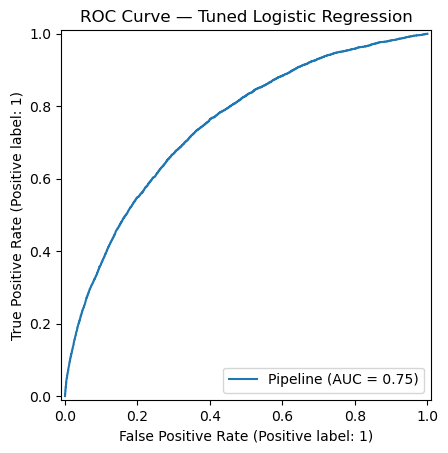

In [43]:
# ROC Curve
# We pass X_test_final (unscaled) because best_model is a Pipeline
# that includes its own StandardScaler internally.
RocCurveDisplay.from_estimator(best_model, X_test_final, y_test)
plt.title('ROC Curve — Tuned Logistic Regression')
plt.show()


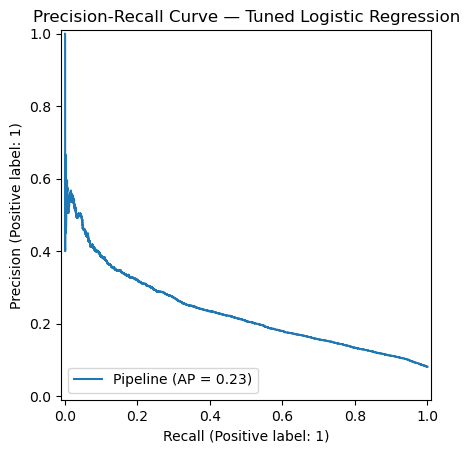

In [44]:
# Precision-Recall Curve
# This is especially informative for imbalanced classification problems.
PrecisionRecallDisplay.from_estimator(best_model, X_test_final, y_test)
plt.title('Precision-Recall Curve — Tuned Logistic Regression')
plt.show()

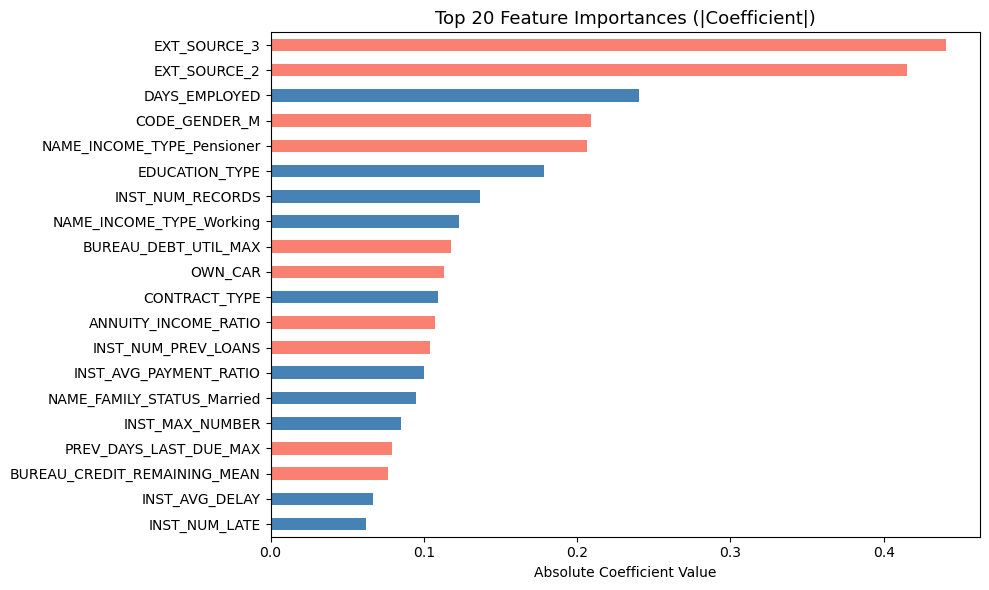

Red = positive contribution to default risk
Blue = negative contribution (protective factor)


In [45]:
# Feature Importance — Top 20 Most Influential Features
# Logistic regression coefficients indicate the direction and magnitude
# of each feature's influence on the predicted probability of default.
feature_names = X_train_final.columns.tolist()
coefs = pd.Series(
    best_model.named_steps['logreg'].coef_[0],
    index=feature_names
)

top20 = coefs.abs().sort_values(ascending=False).head(20)

colors = ['salmon' if coefs[f] > 0 else 'steelblue' for f in top20.index]
fig, ax = plt.subplots(figsize=(10, 6))
top20.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Top 20 Feature Importances (|Coefficient|)', fontsize=13)
ax.set_xlabel('Absolute Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Red = positive contribution to default risk')
print('Blue = negative contribution (protective factor)')


According to the ROC curve, our model achieves an AUC of 0.72, meaning that if we randomly select one actual defaulter and one actual good borrower, the model correctly ranks the defaulter as higher risk 72% of the time which is better than random guessing (AUC = 0.50). Looking at the shape of the curve, we can see a steep rise on the left side, meaning that at low false positive rates, our model already captures a really high proportion of real defaulters. While we do flag some good borrowers incorrectly in the process, the steep early rise confirms that real defaulters are identified before a large number of false alarms occur which is exactly what we need for a credit risk model.

## Choose a threshold

We decide to choose the threshold value of 0.4 based on the the business question: should we prioritize minimizing default losses or maximizing profit from approved loans? In a typical credit lending problem, the cost of a false negative (approving a borrower who defaults) is substantially higher than the cost of a false positive (rejecting a borrower who would have repaid). 

In [46]:
# Class predictions at custom threshold
threshold = 0.4
y_pred = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

Threshold: 0.4
Accuracy: 0.5492902785229988

Classification Report:
               precision    recall  f1-score   support

           0     0.9695    0.5262    0.6822     56538
           1     0.1308    0.8117    0.2253      4965

    accuracy                         0.5493     61503
   macro avg     0.5502    0.6690    0.4537     61503
weighted avg     0.9018    0.5493    0.6453     61503



In [47]:
# Export model prediction for building dashboard in PowerBI
model_output = pd.DataFrame({
    'SK_ID_CURR':          merged_df['SK_ID_CURR'].iloc[X_test_final.index].values,
    'DEFAULT_PROBABILITY': y_proba,
    'PREDICTED_DEFAULT':   (y_proba >= 0.4).astype(int),
    'ACTUAL_DEFAULT':      y_test.values
})

conn = sqlite3.connect('loan_default.db')
model_output.to_sql('model_output', conn, if_exists='replace', index=False)
conn.close()
print("Model output exported!")
print(model_output.head())

Model output exported!
   SK_ID_CURR  DEFAULT_PROBABILITY  PREDICTED_DEFAULT  ACTUAL_DEFAULT
0      100002             0.453453                  1               0
1      100003             0.432977                  1               0
2      100004             0.805884                  1               0
3      100006             0.540900                  1               0
4      100007             0.602004                  1               0


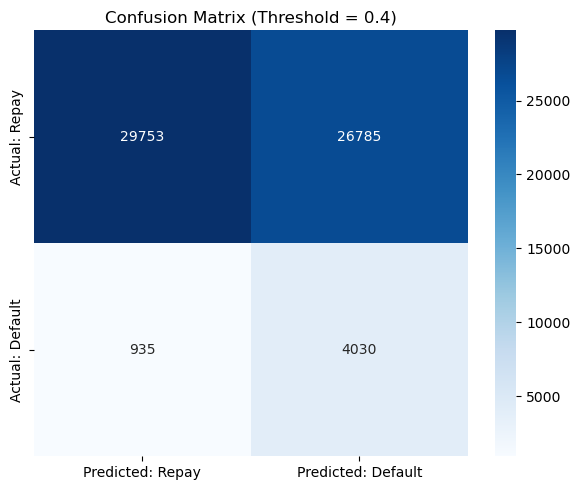

In [48]:
# Confusion Matrix at threshold = 0.4
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predicted: Repay', 'Predicted: Default'],
    yticklabels=['Actual: Repay', 'Actual: Default']
)
ax.set_title(f'Confusion Matrix (Threshold = 0.4)', fontsize=12)
plt.tight_layout()
plt.show()


### Confusion Matrix Summary
The confusion matrix shows that our model correctly approves 29,739 good borrowers who do not default, and correctly identifies 4,026 true defaulters who would have defaulted. Out of 4,965 total actual defaulters, our model only misses 939 real defaulters which confirms that our model successfully catches 81% of all actual defaulters.

### Financial Assumptions

The cost-benefit analysis above uses the following illustrative assumptions:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Average loan amount | $500,000 | Approximation based on Home Credit's publicly reported loan portfolio |
| Default loss rate | 60% | Industry standard estimate: lenders typically recover ~40% on defaulted loans |
| Opportunity cost rate | 8% | Estimated annual interest revenue foregone per incorrectly rejected borrower |

These values are illustrative. A production deployment would use lender-specific actuals from accounting records to compute true expected costs.


In [49]:
avg_loan = 500_000
default_loss_rate = 0.60
interest_rate = 0.08

thresholds = np.arange(0.25, 0.75, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    cost_fp = fp * avg_loan * interest_rate
    cost_fn = fn * avg_loan * default_loss_rate
    net_cost = cost_fp + cost_fn
    saved = tp * avg_loan * default_loss_rate
    
    results.append({
        'Threshold': round(t, 2),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'FP Cost ($)': cost_fp,
        'FN Cost ($)': cost_fn,
        'Net Cost ($)': net_cost,
        'Losses Prevented ($)': saved
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Net Cost ($)')

# Format as dollars
dollar_cols = ['FP Cost ($)', 'FN Cost ($)', 'Net Cost ($)', 'Losses Prevented ($)']
results_df[dollar_cols] = results_df[dollar_cols].apply(lambda col: col.map(lambda x: f"${x:,.0f}"))

display(results_df)

,Threshold,TN,FP,FN,TP,FP Cost ($),FN Cost ($),Net Cost ($),Losses Prevented ($)
7,0.60,46284,10254,2375,2590,"$410,160,000","$712,500,000","$1,122,660,000","$777,000,000"
8,0.65,49209,7329,2824,2141,"$293,160,000","$847,200,000","$1,140,360,000","$642,300,000"
6,0.55,42807,13731,1971,2994,"$549,240,000","$591,300,000","$1,140,540,000","$898,200,000"
5,0.50,38946,17592,1584,3381,"$703,680,000","$475,200,000","$1,178,880,000","$1,014,300,000"
9,0.70,51601,4937,3303,1662,"$197,480,000","$990,900,000","$1,188,380,000","$498,600,000"
4,0.45,34619,21919,1231,3734,"$876,760,000","$369,300,000","$1,246,060,000","$1,120,200,000"
3,0.40,29753,26785,935,4030,"$1,071,400,000","$280,500,000","$1,351,900,000","$1,209,000,000"
2,0.35,24480,32058,663,4302,"$1,282,320,000","$198,900,000","$1,481,220,000","$1,290,600,000"
1,0.30,19128,37410,422,4543,"$1,496,400,000","$126,600,000","$1,623,000,000","$1,362,900,000"
0,0.25,13466,43072,246,4719,"$1,722,880,000","$73,800,000","$1,796,680,000","$1,415,700,000"


While our model was tuned at threshold 0.40 to prioritize recall (0.81), the financial cost analysis reveals that threshold 0.60 minimizes estimated net cost at ~$1.12B. The bank should select a threshold based on its strategy:

- **Threshold 0.40** — Maximizes recall (catches more defaulters); recommended when minimizing default losses is the primary goal.
- **Threshold 0.60** — Minimizes total financial cost; recommended when the two opposing costs from flagging non-defaulters as defaulters and flagging real defaulters as non-defaulters balance out at their lowest combined total.

All in all, there is no correct threshold because we believe that this depends on the decision maker and their goal with their business.

### Summary
Do note that the model has a threshold of 0.4 and the model generalizes the predictions very well and that there is no overfitting in the model. Our ROC_AUC, which is also seen in the ROC curve, lets us know that our model correctly ranks a defaulter over a non-defaulter 75% of the time.  

However, We have a low precision and F1 score, which is expected.  We are prioritizing recall due to wanting to identify more potential defaulters. By doing this, we will inevitably have a low precision and F1 score due to the precision-recall trade-off.

# Conclusion

## Key Results

| Metric | Value |
|--------|-------|
| ROC-AUC | 0.75 |
| Recall (Default class, threshold=0.4) | ~0.81 |
| Precision (Default class, threshold=0.4) | ~0.27 |
| Defaulters correctly identified | 4,026 of 4,965 |

Our logistic regression model correctly flags 81 out of every 100 actual defaulters before loan approval, and ranks a defaulter above a non-defaulter 75% of the time (ROC-AUC = 0.75).

## Feature Engineering Impact

Incorporating credit history (`bureau`), installment payment behavior (`installments_payments`), and previous application outcomes (`previous_application`) — and engineering ratio-based features from correlated raw variables — produced a richer feature set than application data alone. Key engineered features include `ANNUITY_INCOME_RATIO`, `LOAN_INCOME_RATIO`, `DEBT_UTILIZATION`, `DAYS_PAYMENT_DELAY`, and `PAYMENT_RATIO`.

## Business Recommendation

We present two operating thresholds for decision-makers:
- **Threshold 0.40** — Maximizes recall; recommended when minimizing default losses is the priority.
- **Threshold 0.60** — Minimizes total estimated net cost (~$1.12B); recommended when balancing approval volume with risk exposure.

## Limitations

- Logistic regression assumes a linear decision boundary and may not capture complex non-linear interactions between features.
- Precision and F1 remain low due to our focus on recall, resulting in a higher false positive rate.
- `PREV_YIELD_GROUP_MODE` had to be dropped entirely due to all values being missing after aggregation.

## Future Work

- Evaluate tree-based models (Random Forest, XGBoost, LightGBM) which can capture non-linear relationships and feature interactions.
- Incorporate the `credit_card_balance` and `POS_CASH_balance` supplementary tables.
- Implement a cost-sensitive threshold optimizer that directly minimizes expected financial loss rather than maximizing recall in isolation.


## Tools & Acknowledgements


AI-assisted code review (Claude, ChatGPT) was used during development to validate implementation patterns, explore feature engineering strategies and code debugging. All modeling decisions, feature selection rationale, and analytical conclusions are our own work.

**Dataset:** Home Credit Default Risk — sourced from [Kaggle](https://www.kaggle.com/competitions/home-credit-default-risk).

**Additional acknowledgements:** We received helpful feedback from fellow students, a business major who provided domain context on lending risk, a data scientist in sports analytics who advised on model evaluation, and Dr. Allen for guidance throughout the course.
